# Proyecto Clasificación de texto

Bienvenidos al proyecto del curso. El presente proyecto consiste en una competencia académica en la que participarán grupos de todas las secciones. El desafío propuesto consiste en desarrollar un sistema de clasificación de textos según su década de origen. El objetivo principal es diseñar un modelo capaz de predecir la década en la que fue escrito un párrafo determinado.

La competencia se divide en dos etapas. En la primera, los participantes deberán emplear técnicas tradicionales de aprendizaje automático, sin recurrir al uso de redes neuronales ni arquitecturas profundas. Esta competencia SOLO corresponde a la primera epata. Posteriormente se le dará mas información sobre la segunda.

Description
Debe diseñar y entrenar un modelo que dado un parágrafo pueda detectar la década de origen del texto

Limitaciones No se permite el uso de técnicas de aprendizaje profundo, especialmente el uso de modelos de lenguaje de tipo transformer. La competencia se deberá realizar en su totalidad usando una combinación de técnicas tradicionales de aprendizaje de maquina y técnicas de PLN.

Evaluación
Las respuestas serán evaluados usando accuracy (puede asumir que no hay desbalance en el dataset de evaluación).

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
df = pd.read_csv("./train.csv")

df.head()

KeyboardInterrupt: 

Activar la GPU del computador

In [2]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5050 Laptop GPU


# EDA

In [ ]:
df.columns

Index(['text', 'decade'], dtype='object')

In [ ]:
df.shape

(31403, 2)

In [ ]:
print(df["text"][0])


Honorarias ¡jubiladas. 57 
dit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 
pag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len 
nes parece que aísilte, O ayuda Calsiodoro 
lib,6.epuft.s 2.Donde * llama Ocloso CINGV- y 19 


In [ ]:
# Ver longitudes
df["text"].apply(len).describe()

count    31403.000000
mean       520.568290
std        530.947792
min        120.000000
25%        182.000000
50%        315.000000
75%        643.000000
max       7418.000000
Name: text, dtype: float64

Hay textos medianamente largos lo cual es bueno, pero hay textos muy largos. El problema potencial es que los textos largos dominen el modelo, se podría limitar a maximo 2000 caracteres lo que evita outliers extremos como un intento de mejora al modelo

In [ ]:
# ver clases (decadas)
df["decade"].value_counts()

decade
160    848
172    842
155    836
170    833
178    831
167    831
154    830
157    827
163    827
180    825
168    822
175    817
171    816
165    814
151    812
179    809
188    809
162    808
182    808
174    807
164    804
185    803
184    802
173    802
159    802
181    795
183    794
156    792
161    787
187    787
150    786
152    785
177    782
166    779
158    778
153    775
186    773
169    771
176    754
Name: count, dtype: int64

Todas las clases tienen 750-850 ejemplos. Hay un dataset balanceado

In [ ]:
# Hay textos vacios?
rta1 = (df["text"].str.strip() == "").sum()
print (f"Numero de textos vacios: {rta1}")
# Hay textos muy cortos?
rta2 = df["text"].apply(len).sort_values().head(10)
print(rta2)

Numero de textos vacios: 0
3075     120
13779    120
10330    120
4271     120
22902    120
10353    120
22255    120
6817     120
29868    120
946      120
Name: text, dtype: int64


No hay textos vacíos, no hay textos demasiado cortos que sean basura, todo tiene minimo contenido util

## Preprocesamiento del texto

Se realizó una limpieza ligera del texto con el objetivo de reducir el ruido presente en el dataset sin eliminar información relevante para la clasificación. Específicamente, se aplicaron las siguientes transformaciones:

* Conversión de todo el texto a minúsculas para evitar duplicidad de tokens por diferencias de capitalización.

* Eliminación de saltos de línea y normalización de espacios, con el fin de evitar la generación de tokens irrelevantes.

* Remoción de caracteres especiales y símbolos no alfabéticos, los cuales provienen principalmente de errores de digitalización (OCR) y no aportan valor semántico al modelo.

Esta limpieza se realizó de forma conservadora, evitando aplicar técnicas más agresivas como stemming o lematización, ya que podrían distorsionar aún más las palabras debido a la naturaleza ruidosa y antigua del corpus.

In [ ]:
# Limpieza en los saltos de linea y espacios extra existentes
df["text"] = df["text"].str.replace("\n", " ")
df["text"] = df["text"].str.replace(r"\s+", " ", regex=True)

In [ ]:
import re

def limpiar_texto(texto):
    texto = texto.lower()
    
    # quitar símbolos raros (deja letras y espacios)
    texto = re.sub(r'[^a-záéíóúñü\s]', '', texto)
    
    return texto

df["text"] = df["text"].apply(limpiar_texto)

Debido al ruido del dataset (OCR y español antiguo), técnicas como stemming no fueron utilizadas, ya que distorsionan aún más las palabras.

Se va a evaluar si el uso de Bolsa de Palabras BOW es el método correcto para este modelo

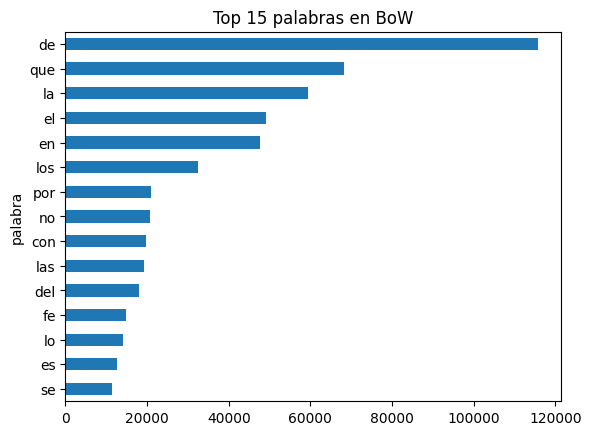

In [ ]:
# Evaluar uso de Bag of words
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

vectorizador_bow = CountVectorizer(max_features=15)

X_bow = vectorizador_bow.fit_transform(df['text'])

counts = X_bow.toarray().sum(axis=0)
words = vectorizador_bow.get_feature_names_out()

# DataFrame para graficar
df_bow = pd.DataFrame({
    'palabra': words,
    'conteo': counts
}).sort_values('conteo', ascending=True)

# Gráfico
df_bow.plot.barh(x='palabra', y='conteo', legend=False)
plt.title("Top 15 palabras en BoW")
plt.show()

El análisis de frecuencia mediante Bag of Words muestra que las palabras más comunes corresponden principalmente a palabras funcionales del idioma (como ‘de’, ‘que’, ‘la’), las cuales aparecen en la mayoría de los documentos independientemente de la década. Estas palabras no aportan valor discriminativo para la tarea de clasificación, ya que no permiten diferenciar entre estilos de escritura de distintas épocas.Esto evidencia una limitación del enfoque Bag of Words, ya que tiende a priorizar términos frecuentes pero poco informativos

Para superar esta limitación, se utilizó TF-IDF, que penaliza palabras comunes y resalta términos más representativos de cada documento.

También, se encontró analizando el dataset que el texto tiene español antiguo como "feñor","hazer","dezir". También hay partes en latin, italiano y francés

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_word = TfidfVectorizer(
    analyzer='word', # Analiza por palabras
    lowercase=True, # Convierte a minúsculas
    ngram_range=(1,2), # Unigramas y bigramas
    min_df=3, #Una palabra aparece en al menos 3 documentos para ser considerada
    max_df=0.9, #Una palabra aparece en como maximo en el 90% de los documentos para ser considerada
    max_features=30000,
    strip_accents='unicode' # Ayuda con caracteres raros, quita tildes automaticamente
)

X_tfidf_word = tfidf_word.fit_transform(df['text'])



Aquí se realizó el preprocesamiento y representación numérica del texto para poder aplicar algoritmos de aprendizaje de máquina. En particular, se aplicó normalización automática del texto mediante la conversión a minúsculas (lowercase=True) y la eliminación de acentos (strip_accents='unicode'), lo que reduce variaciones innecesarias en las palabras (por ejemplo, “Revolución” y “revolucion” se consideran iguales). Luego, el texto se transformó en un conjunto de características usando TF-IDF, que asigna un peso a cada palabra según su importancia relativa en los documentos. Se utilizaron unigramas y bigramas (ngram_range=(1,2)), lo que permite capturar tanto palabras individuales como combinaciones de dos palabras que pueden reflejar estilo lingüístico de una época. Además, se aplicó un filtrado estadístico de vocabulario: min_df=3 elimina palabras extremadamente raras que aparecen en menos de tres documentos (reduciendo ruido y varianza), mientras que max_df=0.9 elimina palabras demasiado frecuentes que aparecen en más del 90% de los textos (como conectores), ya que aportan poca capacidad de discriminación entre décadas. Finalmente, se limitó el vocabulario a las 30,000 características más relevantes (max_features=30000) para controlar la dimensionalidad y mejorar la capacidad de generalización del modelo. El resultado es una matriz numérica X_tfidf_word que representa cada texto como un vector de características listo para entrenar modelos de clasificación.

In [ ]:
print("Vocabulario:")
print(tfidf_word.get_feature_names_out()[:50])

Vocabulario:
['aa' 'aaa' 'aan' 'aaron' 'aas' 'ab' 'ab ea' 'ab eo' 'aba' 'abad'
 'abad de' 'abad que' 'abades' 'abadia' 'abajo' 'aban' 'abandonar'
 'abandono' 'abarca' 'abate' 'abatido' 'abaxo' 'abb' 'abe' 'abel' 'aben'
 'aber' 'abertura' 'abi' 'abia' 'abierta' 'abierta la' 'abiertamente'
 'abiertas' 'abierto' 'abiertos' 'abito' 'ablandar' 'abo' 'abogado'
 'abogados' 'abolicion' 'abominable' 'abona' 'abono' 'aborrece'
 'aborrecido' 'aborrecimiento' 'about' 'abr']


In [ ]:
print("Vector TF-IDF del documento 1:")
print(X_tfidf_word[0].toarray())

Vector TF-IDF del documento 1:
[[0. 0. 0. ... 0. 0. 0.]]


In [ ]:
doc_vector = X_tfidf_word[0].toarray().flatten()

df_importancia = pd.DataFrame({
    "ngram": tfidf_word.get_feature_names_out(),
    "peso": doc_vector
})

df_importancia = df_importancia.sort_values(by="peso", ascending=False)

df_importancia.head(50)

,ngram,peso
1448,aqu,0.425869
26838,ste,0.406595
16695,len,0.350376
2050,ayuda,0.319789
21280,pag,0.303428
21561,parece que,0.298827
17027,llama,0.264768
19755,nes,0.264186
21553,parece,0.245251
8233,donde,0.194187


* En este caso se evidencia que aparecen cosas raras como "aqu","ste","len","pag" esto pasa porque está capturando fragmentos de palabras, dataset tiene:
    1. Texto antiguo
    2. Errores de digitalización (OCR)
    3. Palabras partidas o mal escaneadas. "Aquí" -> Aparece como "aqu" 
    4. Raíces comunes

* Además, el dataset parece tener texto digitalizado, variantes ortográficas y/o palabras truncadas lo que es común en corpus históricos. Es importante porque las décadas tienen ortografía distinta. Por ejemplo, en el siglo XVII -> "dixo" pero en el siglo XX -> "Dijo"

* Los bigramas como "parece que" pueden ser útiles porque capturan estilo linguístico.

* "Ayuda", "Donde", "Llama", "Parece" indican tema, estilo, periodo histórico


In [ ]:
print(f"largo del dataframe: {len(df)}") # Hay 31k documentos
print(f"largo del vocabulario: {len(tfidf_word.get_feature_names_out())}") # Hay 30k ngrams

largo del dataframe: 31403
largo del vocabulario: 30000


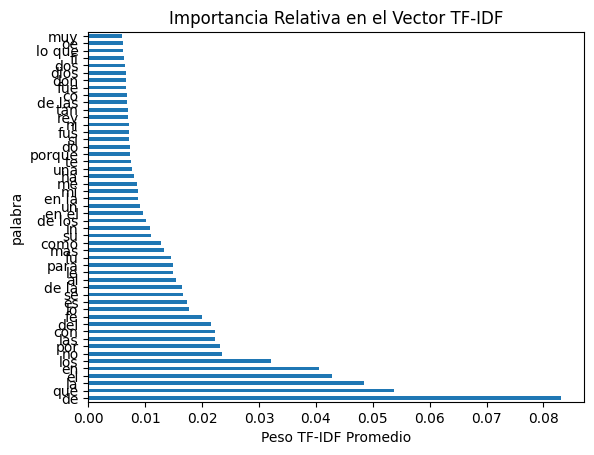

In [ ]:
vocab = tfidf_word.get_feature_names_out()
pesos = X_tfidf_word.mean(axis=0).A1
df_resumen = pd.DataFrame({'palabra': vocab, 'peso': pesos}).sort_values('peso', ascending=False).head(50)

df_resumen.plot.barh(x='palabra', y='peso', legend=False)
plt.title("Importancia Relativa en el Vector TF-IDF")
plt.xlabel("Peso TF-IDF Promedio")
plt.show()

En la grafica nos podemos dar cuenta que la mayoría de palabras con mayor peso son stop-words del español como muy, lo que, dos, de las. Además, palabras que tienen tres letras o menos como "ste" o "nes" así que se va a proceder a eliminarlas

In [ ]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

tfidf_word = TfidfVectorizer(
    analyzer='word', # Analiza por palabras
    lowercase=True, # Convierte a minúsculas
    ngram_range=(1,1), # Unigramas
    min_df=5, #Una palabra aparece en al menos 3 documentos para ser considerada
    max_df=0.9, #Una palabra aparece en como maximo en el 90% de los documentos para ser considerada
    stop_words=stopwords.words('spanish'), # Agregar stopwords personalizadas
    token_pattern=r'(?u)\b\w\w\w+\b', # Solo palabras de 3 o más caracteres
    max_features=30000,
    strip_accents='unicode' # Ayuda con caracteres raros, quita tildes automaticamente
)

X_tfidf_word = tfidf_word.fit_transform(df['text'])


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eramos', 'estabamos', 'estais', 'estan', 'estara', 'estaran', 'estaras', 'estare', 'estareis', 'estaria', 'estariais', 'estariamos', 'estarian', 'estarias', 'esteis', 'esten', 'estes', 'estuvieramos', 'estuviesemos', 'fueramos', 'fuesemos', 'habeis', 'habia', 'habiais', 'habiamos', 'habian', 'habias', 'habra', 'habran', 'habras', 'habre', 'habreis', 'habria', 'habriais', 'habriamos', 'habrian', 'habrias', 'hayais', 'hubieramos', 'hubiesemos', 'mas', 'mia', 'mias', 'mio', 'mios', 'seais', 'sera', 'seran', 'seras', 'sere', 'sereis', 'seria', 'seriais', 'seriamos', 'serian', 'serias', 'tambien', 'tendra'

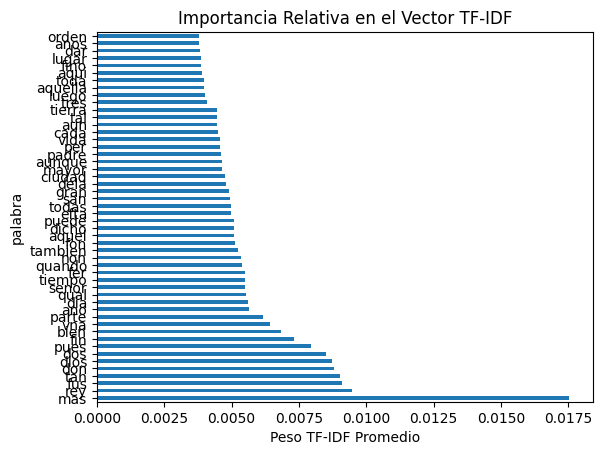

In [ ]:
vocab = tfidf_word.get_feature_names_out()
pesos = X_tfidf_word.mean(axis=0).A1
df_resumen = pd.DataFrame({'palabra': vocab, 'peso': pesos}).sort_values('peso', ascending=False).head(50)

df_resumen.plot.barh(x='palabra', y='peso', legend=False)
plt.title("Importancia Relativa en el Vector TF-IDF")
plt.xlabel("Peso TF-IDF Promedio")
plt.show()

In [ ]:
df_resumen

,palabra,peso
16868,mas,0.017534
23982,rey,0.009463
12300,fus,0.009115
25480,tan,0.009013
8395,don,0.008783
8049,dios,0.008744
8446,dos,0.008492
22328,pues,0.007957
11526,fin,0.007326
2996,bien,0.006840


El resultado muestra que, después de aplicar normalización, filtrado por frecuencia (min_df, max_df) y eliminación de stopwords, el vocabulario TF-IDF está compuesto principalmente por palabras con contenido semántico e histórico relevante, como rey, dios, señor, ciudad, tiempo, tierra, padre, así como variantes ortográficas antiguas como qual, quando, non, vna, dela, efta. Esto indica que el preprocesamiento logró reducir palabras funcionales muy frecuentes (por ejemplo de, la, que) que no aportan capacidad discriminativa, permitiendo que el modelo capture patrones lingüísticos propios de distintas épocas. En particular, la presencia de formas antiguas del español sugiere que el modelo podrá aprender diferencias temporales en el uso del lenguaje, lo cual es clave para predecir la década de origen del texto. En términos de aprendizaje de máquina, se logró una representación con menor ruido y mejor balance entre sesgo y varianza, conservando características con mayor poder predictivo para la tarea de clasificación.

Como una observación interesante se evidencia que aparecen muchas variantes antiguas "qual" -> "cual", "quando" -> "cuando", "non" -> "no", "vna" -> "una", "dela" -> "de la" lo que indica que las décadas tienen patrones ortográficos distintos

## Entrenar diferentes modelos

In [ ]:
y = df['decade']
x = X_tfidf_word
print(X_tfidf_word.shape)
print(y.shape)

NameError: name 'X_tfidf_word' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf_word,
    y,
    test_size=0.2,
    random_state=42
)


Modelo de regresión logística

In [ ]:
from sklearn.linear_model import LogisticRegression

# Entrenar un modelo de regresión logística
model = LogisticRegression(max_iter=3000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         150       0.50      0.65      0.56       158
         151       0.28      0.49      0.36       167
         152       0.46      0.57      0.51       183
         153       0.26      0.38      0.31       156
         154       0.32      0.47      0.38       162
         155       0.20      0.16      0.18       172
         156       0.27      0.39      0.32       143
         157       0.11      0.14      0.12       153
         158       0.19      0.18      0.18       164
         159       0.12      0.13      0.13       151
         160       0.08      0.06      0.07       174
         161       0.11      0.09      0.10       151
         162       0.18      0.13      0.15       170
         163       0.15      0.12      0.13       160
         164       0.13      0.09      0.11       170
         165       0.08      0.06      0.07       173
         166       0.06      0.03      0.04       154
         167       0.11    

Modelo de Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)
y_pred = model_nb.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         150       0.42      0.66      0.52       158
         151       0.31      0.45      0.37       167
         152       0.77      0.49      0.60       183
         153       0.26      0.26      0.26       156
         154       0.26      0.59      0.36       162
         155       0.17      0.21      0.19       172
         156       0.42      0.32      0.36       143
         157       0.12      0.14      0.13       153
         158       0.23      0.18      0.21       164
         159       0.14      0.33      0.20       151
         160       0.07      0.06      0.06       174
         161       0.12      0.10      0.11       151
         162       0.17      0.16      0.17       170
         163       0.12      0.11      0.12       160
         164       0.12      0.09      0.10       170
         165       0.11      0.02      0.04       173
         166       0.15      0.03      0.04       154
         167       0.13    

In [ ]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()

model_svm.fit(X_train, y_train)

y_pred = model_svm.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         150       0.61      0.67      0.64       158
         151       0.41      0.46      0.43       167
         152       0.54      0.57      0.55       183
         153       0.33      0.33      0.33       156
         154       0.31      0.39      0.34       162
         155       0.16      0.16      0.16       172
         156       0.25      0.27      0.26       143
         157       0.09      0.12      0.10       153
         158       0.19      0.18      0.18       164
         159       0.11      0.12      0.11       151
         160       0.05      0.05      0.05       174
         161       0.08      0.09      0.08       151
         162       0.12      0.11      0.12       170
         163       0.10      0.09      0.09       160
         164       0.11      0.09      0.10       170
         165       0.09      0.08      0.08       173
         166       0.07      0.06      0.07       154
         167       0.11    

## Pipeline para entrenar diferentes parametros y diferentes modelos

In [ ]:
y = df['decade']
x = df["text"]

print(X_tfidf_word.shape)
print(y.shape)

NameError: name 'X_tfidf_word' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y #Importante para clasificación multiclase, asegura que cada clase esté representada proporcionalmente en train y test
)


In [ ]:
# Función de limpieza
import re

def limpiar_texto(textos):

    textos = textos.str.replace("\n", " ", regex=False)

    textos = textos.str.replace(r"\s+", " ", regex=True)

    textos = textos.str.lower()

    textos = textos.apply(lambda x: re.sub(r'[^a-záéíóúñü\s]', '', x))

    return textos

Pipeline Naive Bayes

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import FunctionTransformer
from nltk.corpus import stopwords


stopwords_es = stopwords.words("spanish")

pipeline_nb = Pipeline([
    ("cleaner", FunctionTransformer(limpiar_texto)),
    ("tfidf", TfidfVectorizer(
        analyzer='word',
        lowercase=True,
        ngram_range=(1,2),
        min_df=5,
        max_df=0.9,
        stop_words=stopwords_es,
        token_pattern=r'(?u)\b\w\w\w+\b',
        max_features=40000,
        strip_accents='unicode'
    )),
    
    ("model", MultinomialNB())
])

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_nb = {

    # parámetros del vectorizador
    "tfidf__ngram_range": [(1,1), (1,2)],
    
    "tfidf__min_df": [3,5],
    
    "tfidf__max_df": [0.85, 0.9],
    
    "tfidf__max_features": [20000, 30000, 40000],

    "tfidf__stop_words": [stopwords_es],

    "tfidf__sublinear_tf": [True, False],

    # parámetro del modelo NB
    "model__alpha": [2.0, 1.0, 0.5, 0.1, 0.05, 0.01]

}

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
grid_nb = GridSearchCV(

    pipeline_nb,

    param_grid_nb,

    cv= KFold(n_splits=5,shuffle = True, random_state=42),

    scoring="accuracy",

    n_jobs=-1, #    Usar todos los núcleos disponibles del procesador para acelerar el proceso

    verbose=1 # Muestra progreso general
)

grid_nb.fit(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eramos', 'estabamos', 'estais', 'estan', 'estara', 'estaran', 'estaras', 'estare', 'estareis', 'estaria', 'estariais', 'estariamos', 'estarian', 'estarias', 'esteis', 'esten', 'estes', 'estuvieramos', 'estuviesemos', 'fueramos', 'fuesemos', 'habeis', 'habia', 'habiais', 'habiamos', 'habian', 'habias', 'habra', 'habran', 'habras', 'habre', 'habreis', 'habria', 'habriais', 'habriamos', 'habrian', 'habrias', 'hayais', 'hubieramos', 'hubiesemos', 'mas', 'mia', 'mias', 'mio', 'mios', 'seais', 'sera', 'seran', 'seras', 'sere', 'sereis', 'seria', 'seriais', 'seriamos', 'serian', 'serias', 'tambien', 'tendra', 'tendran', 'tendras', 'tendre', 'tendreis', 'tendria', 'tendriais', 'tendriamos', 'tendrian', 'tendrias', 'teneis', 'tengais', 'tenia', 'teniais', 'teniamos',

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...inomialNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [2.0, 1.0, ...], 'tfidf__max_df': [0.85, 0.9], 'tfidf__max_features': [20000, 30000, ...], 'tfidf__min_df': [3, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [ ]:
params = grid_nb.best_params_
best_model = grid_nb.best_estimator_ 

print(params)
print(best_model)

{'model__alpha': 0.1, 'tfidf__max_df': 0.85, 'tfidf__max_features': 40000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2), 'tfidf__stop_words': ['de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus', 'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 'mía', 'míos', 'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya', 'suyos', 'suyas', 'nuestro', 'nuestra'

In [ ]:
from sklearn.metrics import classification_report
y_pred = best_model.predict(X_test)

#Metricas
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         150       0.59      0.68      0.63       157
         151       0.34      0.54      0.42       162
         152       0.62      0.43      0.51       157
         153       0.31      0.46      0.37       155
         154       0.40      0.54      0.46       166
         155       0.24      0.22      0.23       167
         156       0.30      0.22      0.25       158
         157       0.14      0.11      0.12       166
         158       0.20      0.23      0.21       156
         159       0.16      0.28      0.20       160
         160       0.07      0.07      0.07       170
         161       0.13      0.10      0.11       157
         162       0.12      0.15      0.13       162
         163       0.11      0.10      0.10       166
         164       0.10      0.11      0.11       161
         165       0.07      0.04      0.05       163
         166       0.08      0.05      0.06       156
         167       0.13    

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_pred)

array([[107,  10,   2, ...,   2,   1,   0],
       [  0,  88,   1, ...,   1,   0,   3],
       [  4,  19,  68, ...,   2,   2,   1],
       ...,
       [  3,   1,   4, ...,  10,  13,  16],
       [  4,   1,   4, ...,   9,  25,  25],
       [  3,   1,   1, ...,  14,  14,  41]], dtype=int64)

## Pipeline Mejorado


Pipeline Naive Bayes y TF-IDF

In [ ]:
y = df['decade']
x = df["text"]

print(x.shape)
print(y.shape)

(31403,)
(31403,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y #Importante para clasificación multiclase, asegura que cada clase esté representada proporcionalmente en train y test
)

In [ ]:
import re
def limpiar_texto(textos):

    textos = textos.str.replace("\n", " ", regex=False)

    textos = textos.str.replace(r"\s+", " ", regex=True)

    textos = textos.str.lower()

    textos = textos.str.replace(r"\d+"," ", regex=True)

    textos = textos.apply(lambda x: re.sub(r'[^a-záéíóúñü\s]', '', x))

    return textos

In [ ]:
from sklearn.pipeline import FeatureUnion,Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import FunctionTransformer
from nltk.corpus import stopwords

stopwords_es = stopwords.words("spanish")


pipeline_m = Pipeline([
    ("cleaner", FunctionTransformer(limpiar_texto)),
    #Unir varias transformaciones de características en paralelo    
    ("features", FeatureUnion([
        ("tfidf", TfidfVectorizer(
            analyzer='word',
            lowercase=True,
            ngram_range=(1,3),
            min_df=4,
            max_df=0.85,
            stop_words=stopwords_es,
            token_pattern=r'(?u)\b\w\w+\b', # Considerar palabras de 2 o más caracteres
            max_features=80000,
            strip_accents='unicode',
            sublinear_tf=True
        )),
        ("char", TfidfVectorizer(

            analyzer="char_wb",
            lowercase=True,
            ngram_range=(3,5),
            min_df=3,
            max_df=0.85,
            max_features=40000,
            strip_accents='unicode'
        ))
    ])),
    ("model", MultinomialNB(alpha=0.1))

])

In [ ]:
param_grid = {

    "features__tfidf__ngram_range": [(1,3),(1,4),(1,5)],
    "features__tfidf__min_df": [3,5,4],
    "features__char__min_df": [3,5,4],
    #"features__tfidf__sublinear_tf": [True, False],
    #"features__char__ngram_range": [(3,5),(3,6),(3,7)],
    #"model__alpha": [0.1,0.2,0.3,0.5,0.8]

}

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
grid_m = GridSearchCV(

    pipeline_m,

    param_grid,

    cv= KFold(n_splits=5,shuffle = True, random_state=42),

    scoring="accuracy",

    n_jobs=-1, #    Usar todos los núcleos disponibles del procesador para acelerar el proceso

    verbose=2 # Muestra progreso general
)

grid_m.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eramos', 'estabamos', 'estais', 'estan', 'estara', 'estaran', 'estaras', 'estare', 'estareis', 'estaria', 'estariais', 'estariamos', 'estarian', 'estarias', 'esteis', 'esten', 'estes', 'estuvieramos', 'estuviesemos', 'fueramos', 'fuesemos', 'habeis', 'habia', 'habiais', 'habiamos', 'habian', 'habias', 'habra', 'habran', 'habras', 'habre', 'habreis', 'habria', 'habriais', 'habriamos', 'habrian', 'habrias', 'hayais', 'hubieramos', 'hubiesemos', 'mas', 'mia', 'mias', 'mio', 'mios', 'seais', 'sera', 'seran', 'seras', 'sere', 'sereis', 'seria', 'seriais', 'seriamos', 'serian', 'serias', 'si', 'tambien', 'tendra', 'tendran', 'tendras', 'tendre', 'tendreis', 'tendria', 'tendriais', 'tendriamos', 'tendrian', 'tendrias', 'teneis', 'tengais', 'tenia', 'teniais', 'teni

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...(alpha=0.1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'features__char__min_df': [3, 5, ...], 'features__tfidf__min_df': [3, 5, ...], 'features__tfidf__ngram_range': [(1, ...), (1, ...), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 

In [ ]:
params = grid_m.best_params_
best_model = grid_m.best_estimator_ 

print(params)
print(best_model)

{'features__char__min_df': 3, 'features__tfidf__min_df': 4, 'features__tfidf__ngram_range': (1, 3)}
Pipeline(steps=[('cleaner',
                 FunctionTransformer(func=<function limpiar_texto at 0x000001A2E41E7880>)),
                ('features',
                 FeatureUnion(transformer_list=[('tfidf',
                                                 TfidfVectorizer(max_df=0.85,
                                                                 max_features=80000,
                                                                 min_df=4,
                                                                 ngram_range=(1,
                                                                              3),
                                                                 stop_words=['de',
                                                                             'la',
                                                                             'que',
                                          

In [ ]:
from sklearn.metrics import classification_report
y_pred = best_model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         150       0.61      0.67      0.64       157
         151       0.25      0.70      0.36       162
         152       0.74      0.45      0.56       157
         153       0.36      0.51      0.42       155
         154       0.44      0.60      0.51       166
         155       0.35      0.22      0.27       167
         156       0.47      0.29      0.36       158
         157       0.17      0.08      0.11       166
         158       0.22      0.26      0.24       156
         159       0.17      0.42      0.24       160
         160       0.13      0.09      0.11       170
         161       0.13      0.10      0.11       157
         162       0.16      0.20      0.18       162
         163       0.16      0.11      0.13       166
         164       0.21      0.18      0.19       161
         165       0.10      0.06      0.07       163
         166       0.13      0.05      0.07       156
         167       0.16    

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[105,  18,   1, ...,   1,   2,   0],
       [  0, 113,   0, ...,   0,   1,   2],
       [  3,  33,  70, ...,   0,   2,   0],
       ...,
       [  4,   2,   2, ...,  11,  12,  36],
       [  3,   3,   3, ...,   9,  25,  37],
       [  1,   3,   0, ...,  17,  15,  48]], dtype=int64)

Pipeline Logistic Regression y TF-IDF

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y #Importante para clasificación multiclase, asegura que cada clase esté representada proporcionalmente en train y test
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords
from sklearn.pipeline import FeatureUnion,Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import FunctionTransformer
from nltk.corpus import stopwords

stopwords_es = stopwords.words("spanish")

pipeline_l = Pipeline([
    ("cleaner", FunctionTransformer(limpiar_texto)),
    #Unir varias transformaciones de características en paralelo    
    ("features", FeatureUnion([
        ("tfidf", TfidfVectorizer(
            analyzer='word',
            lowercase=True,
            ngram_range=(1,3),
            min_df=3,
            max_df=0.85,
            stop_words=stopwords_es,
            token_pattern=r'(?u)\b\w+\b', # Considerar palabras de 1 o más caracteres
            max_features=80000,
            strip_accents='unicode',
            sublinear_tf=True
        )),
        ("char", TfidfVectorizer(

            analyzer="char_wb",
            lowercase=True,
            ngram_range=(3,5),
            min_df=3,
            max_df=0.85,
            max_features=40000,
            strip_accents='unicode'
        ))
    ])),
    ("model", LogisticRegression(C=0.9, max_iter=4000))

])

In [ ]:
param_grid_l= {

    #"features__tfidf__ngram_range": [(1,3),(1,4)],
    #"features__tfidf__min_df": [3,5,4],
    #"features__char__min_df": [3,5,4],
    #"model__C": [0.8,0.6,0.7,0.9], -> 0.9
    #"features__tfidf__sublinear_tf": [True, False],
    #"features__char__ngram_range": [(3,5),(3,6),(3,7)],
    #"model__alpha": [0.1,0.2,0.3,0.5,0.8]

}
    

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
grid_l = GridSearchCV(

    pipeline_l,

    param_grid_l,

    cv= KFold(n_splits=5,shuffle = True, random_state=42),

    scoring="accuracy",

    n_jobs=-1, #    Usar todos los núcleos disponibles del procesador para acelerar el proceso

    verbose=2 # Muestra progreso general
)

grid_l.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eramos', 'estabamos', 'estais', 'estan', 'estara', 'estaran', 'estaras', 'estare', 'estareis', 'estaria', 'estariais', 'estariamos', 'estarian', 'estarias', 'esteis', 'esten', 'estes', 'estuvieramos', 'estuviesemos', 'fueramos', 'fuesemos', 'habeis', 'habia', 'habiais', 'habiamos', 'habian', 'habias', 'habra', 'habran', 'habras', 'habre', 'habreis', 'habria', 'habriais', 'habriamos', 'habrian', 'habrias', 'hayais', 'hubieramos', 'hubiesemos', 'mas', 'mia', 'mias', 'mio', 'mios', 'seais', 'sera', 'seran', 'seras', 'sere', 'sereis', 'seria', 'seriais', 'seriamos', 'serian', 'serias', 'si', 'tambien', 'tendra', 'tendran', 'tendras', 'tendre', 'tendreis', 'tendria', 'tendriais', 'tendriamos', 'tendrian', 'tendrias', 'teneis', 'tengais', 'tenia', 'teniais', 'teni

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=4000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate

In [ ]:
print("NB best:", grid_m.best_score_)

print("LR best:", grid_l.best_score_)

NB best: 0.2227928034984314
LR best: 0.2292416421079317


In [ ]:
params = grid_l.best_params_
best_model = grid_l.best_estimator_ 
print("LR best:", grid_l.best_score_)
print(params)
print(best_model)

pipeline_final = best_model

LR best: 0.2292416421079317
{}
Pipeline(steps=[('cleaner',
                 FunctionTransformer(func=<function limpiar_texto at 0x000001E1BAD77740>)),
                ('features',
                 FeatureUnion(transformer_list=[('tfidf',
                                                 TfidfVectorizer(max_df=0.85,
                                                                 max_features=80000,
                                                                 min_df=3,
                                                                 ngram_range=(1,
                                                                              3),
                                                                 stop_words=['de',
                                                                             'la',
                                                                             'que',
                                                                             'el',
                            

In [ ]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test,y_pred))

NameError: name 'classification_report' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[112,  11,   2, ...,   1,   0,   0],
       [  1, 106,   1, ...,   1,   0,   1],
       [  3,  18,  82, ...,   1,   1,   3],
       ...,
       [  2,   0,   3, ...,  17,  19,  20],
       [  3,   2,   5, ...,   9,  26,  26],
       [  1,   2,   1, ...,  13,  21,  32]], dtype=int64)

In [ ]:
import pandas as pd

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(cm)

print(cm_df)

     0    1   2   3   4   5   6   7   8   9   ...  29  30  31  32  33  34  35  \
0   112   11   2   7   5   1   0   4   0   0  ...   1   5   1   0   1   1   1   
1     1  106   1   9  10   5   0   2   3   1  ...   1   0   0   2   2   3   4   
2     3   18  82  10   9   5   1   3   1   1  ...   1   0   4   1   2   0   1   
3     0   12   0  90  25   3   3  10   1   0  ...   0   2   0   0   0   0   0   
4     2   12   1  17  91   8   3   2   9   1  ...   0   1   0   1   1   0   0   
5     1   12   1  17  16  44   9  13  14   6  ...   0   0   1   2   1   0   2   
6     1    3   3   7  13   7  62   9  11  11  ...   1   0   1   0   0   0   0   
7     0    9   0   5   1  13   9  46  13  14  ...   0   1   0   0   0   0   1   
8     0    1   0   4   4   7   7  18  40  34  ...   0   1   0   1   0   0   0   
9     0    6   0   2   1   8   9   8  17  42  ...   0   0   0   0   0   0   0   
10    3    2   0   0   0   4  19  10  13  19  ...   0   0   0   3   0   0   0   
11    0    1   1   8   0   4

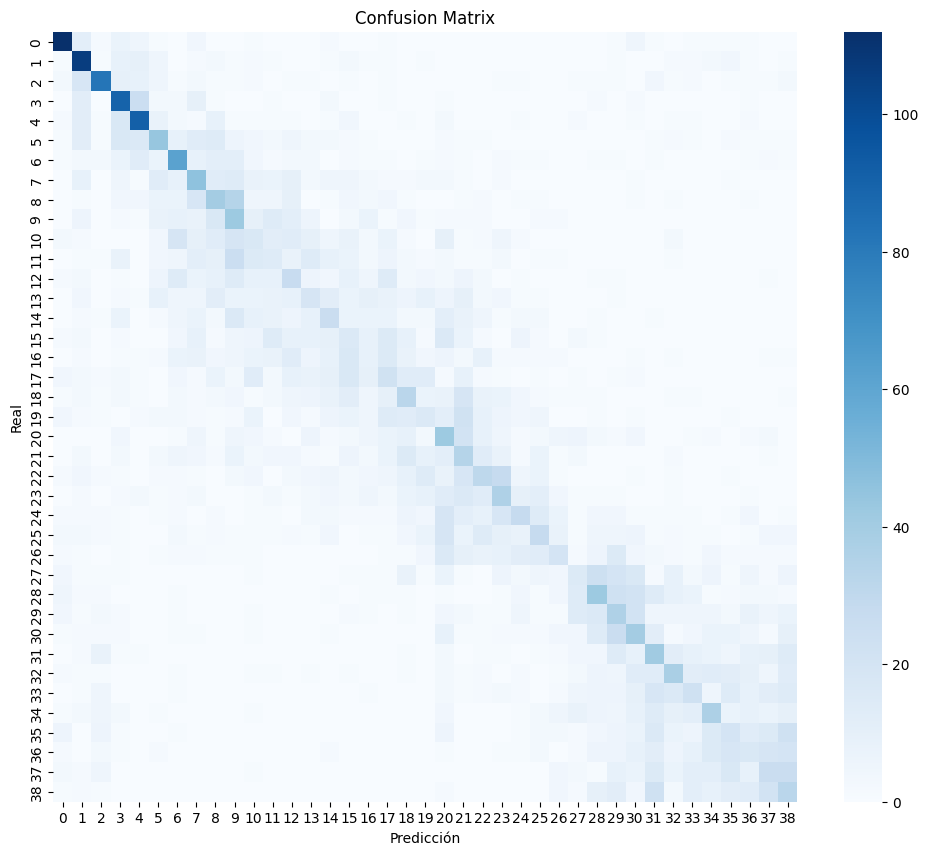

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(cm_df, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

In [ ]:
errores_por_clase = cm_df.sum(axis=1) - cm_df.values.diagonal()

errores_por_clase.sort_values(ascending=False).head(10)

10    153
15    147
16    147
13    147
17    144
11    143
35    141
27    141
19    138
36    138
dtype: int64

In [ ]:
indices = [10,15,16,13,17,11,35,27,19,36]

decadas = [150 + i for i in indices]

print(decadas)

[160, 165, 166, 163, 167, 161, 185, 177, 169, 186]


In [ ]:
for decada in [160, 165, 166, 163, 167, 161, 185, 177, 169, 186]:

    i = decada - 150
    
    print("\nDécada real:", decada)
    
    print(cm_df.iloc[i].sort_values(ascending=False).head(5))


Década real: 160
6     19
9     19
10    17
8     13
12    13
Name: 10, dtype: int64

Década real: 165
15    16
20    16
17    15
11    14
14    10
Name: 15, dtype: int64

Década real: 166
15    17
17    15
12    13
14     9
22     9
Name: 16, dtype: int64

Década real: 163
13    19
14    12
8     12
21    10
16    10
Name: 13, dtype: int64

Década real: 167
17    22
15    17
19    13
18    13
10    13
Name: 17, dtype: int64

Década real: 161
9     25
10    15
13    14
11    14
7     11
Name: 11, dtype: int64

Década real: 185
38    23
35    20
31    16
37    15
34    15
Name: 35, dtype: int64

Década real: 177
28    24
29    20
30    17
27    15
32     9
Name: 27, dtype: int64

Década real: 169
21    22
19    16
17    14
18    13
20    11
Name: 19, dtype: int64

Década real: 186
38    20
37    19
35    18
36    17
34    15
Name: 36, dtype: int64


El análisis de la matriz de confusión muestra que el modelo tiene mayor dificultad para distinguir entre décadas cercanas en el tiempo, especialmente entre los años 156–163, 168–171, 177–178 y 181–186. Esto indica que el modelo sí está capturando correctamente la evolución histórica del lenguaje, ya que la mayoría de los errores ocurren entre periodos consecutivos donde los cambios lingüísticos son graduales y no abruptos. Es decir, el vocabulario, la ortografía y las estructuras gramaticales se parecen mucho entre décadas próximas, lo que hace que el modelo confunda textos temporalmente similares. Sin embargo, el hecho de que la mayoría de las predicciones correctas se concentren en la diagonal de la matriz demuestra que las características utilizadas (TF-IDF con n-gramas de palabras y caracteres) son adecuadas para modelar la evolución del español a lo largo del tiempo, ya que el modelo rara vez confunde textos de siglos muy diferentes. En conclusión, el modelo aprende patrones lingüísticos históricos relevantes, pero la alta similitud entre décadas consecutivas limita la precisión máxima alcanzable.

## Mejorar pipeline Logistic Regression

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
df = pd.read_csv("./train.csv")

df.head()

,text,decade
0,"\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \nnes parece que aísilte, O ayuda Calsiodoro \nlib,6.epuft.s 2.Donde * llama Ocloso CINGV- y 19",164
1,"gone. Sus amigos , sus clientes, todo \ncuanto le rodea le prueban que es hom- \nbre de mucha importancia. Si ve que al- \ngunos hombre» plebeyos á fuerza de ser- \nvicios y de hazañas se elevan de la cla- \nse en que nacieron, se consuela dicien- \ndo: puús para lles^nr á la '-hxe en ijue \nestoy ^ todavia necesita su familia de mu- \nchos años de antigüedad.",182
2,"Prefosen quemanera,e per qualesfolpechas deuan feratormentados, e \nante quien,e quie preguntasles deuan hazer mientras los tormentarf, \nvecla.lstitopuzo",157
3,"Caistro el M a y o r a i .] Del apellido de Cañroíe \nvalió Don Luis enefta. Metáfora, para el nombre que fupo \nne de Caiftro. Mayoral fe llama entre los ganaderos el \nque tiene el primer lugar, y a quien efián fujetos los de¬ \nmas, y defia mayoría tomó el nombte.",163
4,"\nlos que panden macho ; y \notros en la fu ña abundan¬ \ncia , íiempre viuen como \nmendigos. La Lana aun en \nel edito fagrado compite \ncon el Sol luzimieutos,' \npues a los dos los llama \nMoy fes Aftros de claridad \nfupsnor , no dando a otra \nEllreliaefta precrogatiua; \nViclt Dsus da ) laminaria \nmagna. Si fe atiende a las \ndcmonílraciones de los Ma \ntemáticos,!* Luna Tolo es \nmayor queMercurio,y me¬ \nnor que todos los d...",166


In [ ]:
# Data Cleaning
# Eliminar textos muy corruptos
def ratio_letras_validas(texto):

    letras = sum(c.isalpha() for c in texto)

    # Recorre cada carácter c del texto.c.isalpha() devuelve True si c es una letra y False si no lo es.
    # Como True vale 1 y False vale 0, sum() cuenta cuántos caracteres del texto son letras.
    # Ejemplo: "hola!!! 123" -> cuenta 4 letras.

    return letras / len(texto) if len(texto)>0 else 0 #número de letras / número total de caracteres

print("DF original:", df.shape)

mask = df["text"].apply(ratio_letras_validas) > 0.62 # Antes tenia 0.6

df = df[mask]

print("DF final:", df.shape)

DF original: (31403, 2)
DF final: (28728, 2)


In [ ]:
y = df['decade']
x = df["text"]

print(x.shape)
print(y.shape)


(28728,)
(28728,)


In [ ]:
def normalizar_ortografia(texto):

    #Reducir la cantidad de formas diferentes de una misma palabra que el modelo tiene que aprender a asociar con la misma clase.
    #Sacado de los textos con errores que no predice bien el modelo
    texto = texto.str.replace("ſ", "s")   # s larga → s normal , coſa -> cosa lo puede ver como palabras distintas , aunque significan lo mismo
    texto = texto.str.replace("ç", "c")   # cedilla → c
    #texto = texto.replace("v","b")
    #texto = texto.replace("z","s")
    texto = texto.str.replace("æ","ae")
    texto = texto.str.replace("œ","oe")
    # variantes antiguas comunes (opcionales)
    #texto = texto.str.replace("ph", "f")   # philosophia → filosofia
    #texto = texto.str.replace("y", "i")    

    texto = texto.str.replace("0","o")
    texto = texto.str.replace("1","l")
    texto = texto.str.replace("3","e")
    texto = texto.str.replace("5","s")
    

    #texto = texto.str.replace("vv","w")
    #texto = texto.str.replace("ii","i")

    texto = texto.str.replace("ﬁ","fi")
    texto = texto.str.replace("ﬂ","fl")


    texto = texto.str.replace(r"(.)\1{2,}", r"\1\1", regex=True) # Reemplaza secuencias de 3 o más caracteres repetidos por solo 2. 
                                                                 #Ejemplo: "loooool" -> "lool". No 1 porque llamar (dos caracteres seguidos)

    return texto

In [ ]:
import re

def limpiar_texto(textos):

    textos = textos.str.lower() #Convierte todo el texto a minúsculas 

    textos = textos.str.replace("\n"," ", regex=False) #Reemplaza saltos de línea (\n) por espacios. 
                                                       #carta del rey /nfelipe -> carta del rey felipe

    textos = textos.str.replace(r"\s+"," ", regex=True) #reemplaza múltiples espacios por uno solo.

    textos = normalizar_ortografia(textos)

    textos = textos.apply(
        lambda x: re.sub(r'[^a-záéíóúñü\s]', ' ', x) #Eliminar todo lo que NO sea minusculas, vocales con tilde
                                                     #ñ,ü y espacios
                                                     # Elimina: 1234567890!@#$%^&*()_+-=~`|\/?";:.,<>[]{}
    )

    return textos

In [ ]:
import numpy as np

def extra_features(textos):

    #Mirar si textos de diferentes épocas pueden tener diferentes longitudes promedio.
    #No funcionó, la longitud del texto no distingue bien las décadas

    length_chars = textos.str.len()

    length_words = textos.str.split().str.len()

    return np.vstack([
 
        length_chars, #Longitud en caracteres

        length_words # Longitud en palabras

    ]).T #Transponer la matriz 


In [ ]:
from langdetect import detect
import numpy as np

def feature_idioma(textos):

    # Idioma detectado en cada texto 

    idiomas = []

    for t in textos:
        try:
            idiomas.append(detect(t)) # Intenta detectar el idioma del texto t usando la función detect() 
                                      # ("es" para español, "en" para inglés, etc.) a la lista idiomas.
        except:
            idiomas.append("unknown")

    idiomas = np.array(idiomas) 

    # convertir a números
    mapping = {
        "es":0,
        "la":1,
        "fr":2,
        "it":3,
        "en":4,
        "unknown":5
    }

    return np.array([mapping.get(i,5) for i in idiomas]).reshape(-1,1) 
    #Convierte los idiomas detectados en números según el diccionario mapping 
    # y devuelve esos valores en formato de columna para que el modelo pueda usarlos
    # como una feature numérica.

In [ ]:
from sklearn.pipeline import FeatureUnion,Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer
from nltk.corpus import stopwords
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import LinearSVC



X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y #Importante para clasificación multiclase, asegura que cada clase esté representada proporcionalmente en train y test
)


stopwords_es = stopwords.words("spanish")

pipeline_mejor = Pipeline([
    ("cleaner", FunctionTransformer(limpiar_texto)),
    #Unir varias transformaciones de características en paralelo    
    ("features", FeatureUnion(
        [
            ("tfidf", TfidfVectorizer(
                analyzer='word',
                lowercase=True,
                ngram_range=(1,3), # Cuando cambie a (1,2) empeoró
                min_df=2, # Con min_df = 3 empeoró
                max_df=0.5, # 0.7 empeora, 0.9 empeora
                stop_words=None,
                token_pattern=r'(?u)\b\w+\b', # Considerar palabras de 1 o más caracteres, cuando elimine las de 1 caracter empeoró
                max_features=90000, # No mejora con 100000
                strip_accents='unicode',
                sublinear_tf=True #Reduce el peso de palabras muy repetidas aplicando una escala logarítmica a la frecuencia del término.
            )),
            ("char", TfidfVectorizer(

                analyzer="char_wb",# Empeora con char
                lowercase=True,
                ngram_range=(3,5), # Se cambio de (3,5) a (3,6) empeora, (4,6) empeora 
                min_df=2,
                max_df=0.85,
                max_features=100000, # antes estaba en 40000
                strip_accents='unicode',
                sublinear_tf=True
            ))
            #("idioma", FunctionTransformer(feature_idioma)) -> No mejora agregar esta feature de idioma
            #("length", FunctionTransformer(extra_features, validate=False)) -> No mejora agregar estas features adicionales
        ])),

    
    ("model", LogisticRegression(C=1.5,max_iter=4000)) # No mejora ponerle  class_weight="balanced", Linear SVC no mejora

])

param_grid_mejor= {
    #"features__char__max_df": [0.85,0.9], -> max_df = 0.85


    #"features__tfidf__ngram_range": [(1,3),(1,4),(1,5)], -> (1,3)
    #"features__tfidf__min_df": [3,5,4], -> min_df = 3
    #"features__char__min_df": [3,5,4], -> min_df = 3 
    #"model__C": [1.3,1.4]  # [0.7,0.9,1.2,1.3] -> 1.3
    #"features__tfidf__sublinear_tf": [True, False], -> sublinear_tf = True
    #"features__char__ngram_range": [(3,5),(3,6),(3,7)] -> (3,5)

}
    

# %%
grid_mejor = GridSearchCV(

    pipeline_mejor,

    param_grid_mejor,

    cv= KFold(n_splits=5,shuffle = True, random_state=42),

    scoring="accuracy",

    n_jobs=-1, # Usar todos los núcleos disponibles del procesador para acelerar el proceso

    verbose=2 # Muestra progreso general
)

grid_mejor.fit(X_train, y_train)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=4000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate

In [ ]:
print("Mejorado best:", grid_mejor.best_score_)

# %%
params = grid_mejor.best_params_
best_model = grid_mejor.best_estimator_
print(params)
print(best_model)

#Mejor hasta ahora  0.23781512605042016

Mejorado best: 0.23962253166584407
{}
Pipeline(steps=[('cleaner',
                 FunctionTransformer(func=<function limpiar_texto at 0x000001E1BD143880>)),
                ('features',
                 FeatureUnion(transformer_list=[('tfidf',
                                                 TfidfVectorizer(max_df=0.5,
                                                                 max_features=90000,
                                                                 min_df=2,
                                                                 ngram_range=(1,
                                                                              3),
                                                                 strip_accents='unicode',
                                                                 sublinear_tf=True,
                                                                 token_pattern='(?u)\\b\\w+\\b')),
                                                ('char',
                         

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
# %%
print("LR best:", grid_l.best_score_)
print("Mejorado best:", grid_mejor.best_score_)

# %%
params = grid_mejor.best_params_
best_model = grid_mejor.best_estimator_ 

print(params)
print(best_model)

# %%
y_pred = best_model.predict(X_test)

print(classification_report(y_test,y_pred))

# %%
confusion_matrix(y_test,y_pred)

LR best: 0.2292416421079317
Mejorado best: 0.23609819133188042
{}
Pipeline(steps=[('cleaner',
                 FunctionTransformer(func=<function limpiar_texto at 0x000001E1BD143880>)),
                ('features',
                 FeatureUnion(transformer_list=[('tfidf',
                                                 TfidfVectorizer(max_df=0.5,
                                                                 max_features=80000,
                                                                 min_df=2,
                                                                 ngram_range=(1,
                                                                              3),
                                                                 strip_accents='unicode',
                                                                 sublinear_tf=True,
                                                                 token_pattern='(?u)\\b\\w+\\b')),
                                                ('char

array([[108,  14,   1, ...,   0,   1,   2],
       [  0,  97,   1, ...,   4,   2,   2],
       [  0,  13,  85, ...,   2,   1,   3],
       ...,
       [  1,   0,   5, ...,  15,  17,  21],
       [  4,   0,   4, ...,  17,  24,  21],
       [  5,   1,   1, ...,  10,  19,  41]], dtype=int64)

In [ ]:
import pandas as pd

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(cm)

print(cm_df)


     0   1   2    3   4   5   6   7   8   9   ...  29  30  31  32  33  34  35  \
0   108  14   1    6   4   0   1   2   0   0  ...   0   1   1   0   2   3   1   
1     0  97   1    6  18   3   0   5   1   2  ...   0   0   1   3   3   5   1   
2     0  13  85   12  13   2   1   0   0   1  ...   0   0   1   1   2   0   0   
3     0  14   1  102  20   5   0   6   1   0  ...   1   0   0   1   0   0   0   
4     2   9   2   22  94   6   2   5   3   1  ...   1   0   0   0   0   2   1   
5     0  14   1   12  17  47   7  16   8  11  ...   1   1   1   0   0   2   1   
6     0   8   1    5  14   3  56  10  11   4  ...   0   0   0   0   0   1   0   
7     0  11   0    2   3  12   6  41  24  17  ...   0   1   0   0   0   0   0   
8     0   6   0    1   1   7   7  11  43  22  ...   0   0   0   0   0   0   0   
9     0   6   1    1   1   4  12  13  14  44  ...   0   0   0   0   0   0   0   
10    1   5   4    1   0   5   8   8  11  12  ...   0   0   0   1   0   0   1   
11    0   4   0    1   0   6

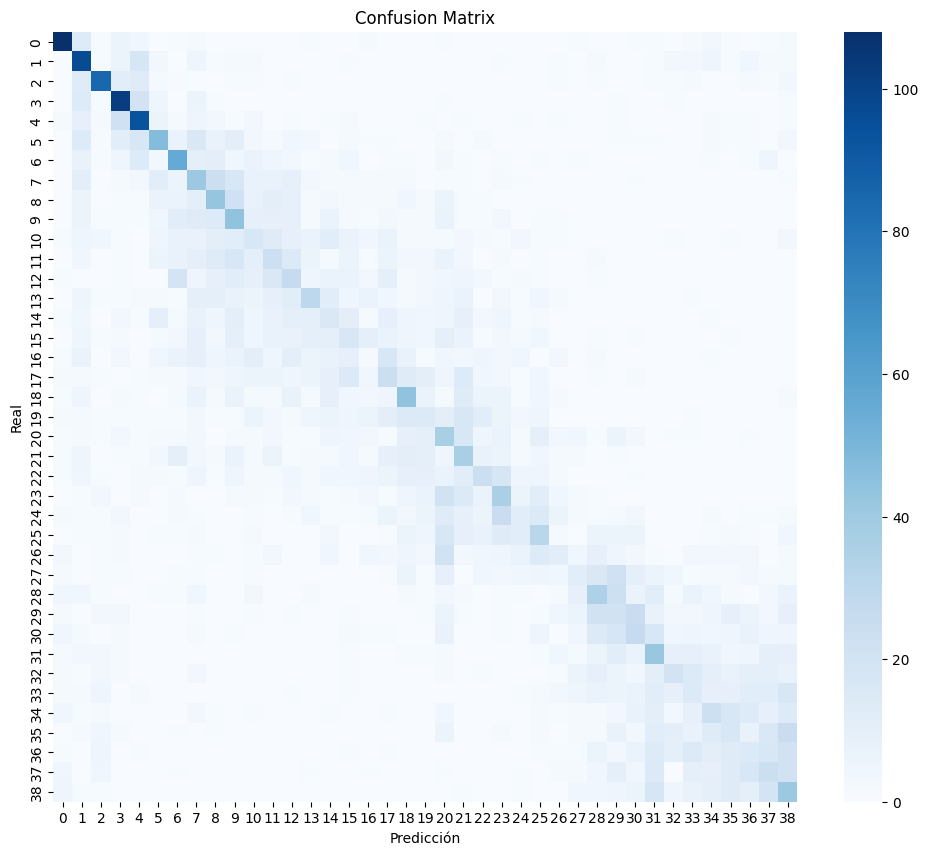

In [ ]:
# %%
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(cm_df, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()



Ver qué esta aprendiendo realmente el modelo, Queremos inspeccionar los betas

In [ ]:
# Identificar cuáles son las 30 features (palabras o n-gramas de caracteres)
# que tienen mayor peso en el modelo de Regresión Logística.
# Esto permite entender qué patrones del texto ayudan más a predecir la década.

# Obtener el bloque "features" del pipeline entrenado (FeatureUnion)
union = grid_mejor.best_estimator_.named_steps["features"]

# Extraer el vectorizador de palabras (TF-IDF word n-grams)
word_vect = union.transformer_list[0][1]

# Extraer el vectorizador de caracteres (TF-IDF char n-grams)
char_vect = union.transformer_list[1][1]

# Obtener los nombres de todas las features creadas por el vectorizador de palabras
# Ejemplo: ["rey", "carta", "rey felipe", "carlos"]
word_features = word_vect.get_feature_names_out()

# Obtener los nombres de todas las features creadas por el vectorizador de caracteres
# Ejemplo: ["car", "art", "tar", "rey"]
char_features = char_vect.get_feature_names_out()

# Unir las features de palabras y caracteres en un solo arreglo
# El modelo entrenó con ambas juntas
feature_names = np.concatenate([word_features, char_features])

# Obtener los coeficientes aprendidos por el modelo de Regresión Logística
# Cada coeficiente indica qué tan importante es una feature para predecir la clase
coef = grid_mejor.best_estimator_.named_steps["model"].coef_

# Ordenar los coeficientes de menor a mayor y seleccionar los índices de las 30 features con mayor peso
# coef[0] corresponde a la primera clase del modelo
top_features = np.argsort(coef[0])[-30:] 

for i in top_features:
    print("")
    print(feature_names[i])

q
 dij
ona
del rey
rey felipe
dona
 su 
felipe
quiera
arta
sobre
carta del
 oe
 car
carlos
 cart
carlos v
aoo
oo 
arta 
dijo
la que
en la que
cart
amadis
carta
su
oe
carta de
carta


Aqui vemos que en las features más importantes aparecen "oo" o "aoo" que no tienen sentido y no ayudan a una correcta clasificación. Por lo tanto, se va utilizar solo el vectorizer para palabras. Además como se evidencia que hay una gran cantidad de features y que algunos presentan la misma raíz de la palabra, se decidió hacer stemming. Adicionalmente, se revisó el dataset enregado y se encontró que habían diferentes idiomas en los textos, por lo tanto, se va a utilizar una librería de google para traducir aquellos textos que no estén en español.

## Modelo Mejorado (Traducción de textos y Stemming)

In [1]:
# Importar librerías necesarias para el proyecto

# =========================
# LIBRERÍAS BÁSICAS
# =========================
import numpy as np
import pandas as pd
import re

# =========================
# VISUALIZACIÓN
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# NLP / TEXTO
# =========================
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from googletrans import Translator
from langdetect import detect
from deep_translator import GoogleTranslator
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor
from skopt.space import Categorical, Integer, Real
from nltk.stem.snowball import SnowballStemmer
# =========================
# VECTORIZACIÓN DE TEXTO
# =========================
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

# =========================
# MODELOS
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from skopt import BayesSearchCV

# =========================
# PIPELINES
# =========================
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer

# =========================
# VALIDACIÓN Y ENTRENAMIENTO
# =========================
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold
)
from sklearn.model_selection import StratifiedKFold
# =========================
# MÉTRICAS
# =========================
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# =========================
# REDUCCIÓN DE DIMENSIONALIDAD
# =========================
from sklearn.decomposition import TruncatedSVD

ModuleNotFoundError: No module named 'deep_translator'

In [42]:
df = pd.read_csv("./train.csv")

df.head()

,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


In [43]:
y = df['decade']
x = df["text"]

print(x.shape)
print(y.shape)


(31403,)
(31403,)


In [44]:
def normalizar_ortografia(texto):

    #Reducir la cantidad de formas diferentes de una misma palabra que el modelo tiene que aprender a asociar con la misma clase.
    #Sacado de los textos con errores que no predice bien el modelo
    texto = texto.str.replace("ſ", "s")   # s larga → s normal , coſa -> cosa lo puede ver como palabras distintas , aunque significan lo mismo
    texto = texto.str.replace("ç", "c")   # cedilla → c
    #texto = texto.replace("v","b")
    #texto = texto.replace("z","s")
    texto = texto.str.replace("æ","ae")
    texto = texto.str.replace("œ","oe")
    # variantes antiguas comunes (opcionales)
    #texto = texto.str.replace("ph", "f")   # philosophia → filosofia
    #texto = texto.str.replace("y", "i")    

    texto = texto.str.replace("0","o")
    texto = texto.str.replace("1","l")
    texto = texto.str.replace("3","e")
    texto = texto.str.replace("5","s")
    

    #texto = texto.str.replace("vv","w")
    #texto = texto.str.replace("ii","i")

    texto = texto.str.replace("ﬁ","fi")
    texto = texto.str.replace("ﬂ","fl")

    # errores OCR comunes en textos antiguos
    texto = texto.str.replace("noftri","nostri")
    texto = texto.str.replace("lefu","iesu")
    texto = texto.str.replace("chrifti","christi")
    texto = texto.str.replace("apoft","apost")
    texto = texto.str.replace("eccl","eccl")
    texto = texto.str.replace("cx","ex")
    

    texto = texto.str.replace(r"(.)\1{2,}", r"\1\1", regex=True) # Reemplaza secuencias de 3 o más caracteres repetidos por solo 2. 
                                                                 #Ejemplo: "loooool" -> "lool". No 1 porque llamar (dos caracteres seguidos)

    return texto

In [7]:
import re

def limpiar_texto(textos):

    textos = textos.str.lower() #Convierte todo el texto a minúsculas 

    textos = textos.str.replace("\n"," ", regex=False) #Reemplaza saltos de línea (\n) por espacios. 
                                                       #carta del rey /nfelipe -> carta del rey felipe

    textos = textos.str.replace(r"\s+"," ", regex=True) #reemplaza múltiples espacios por uno solo.

    textos = normalizar_ortografia(textos)

    textos = textos.apply(
        lambda x: re.sub(r'[^a-záéíóúñü\s]', ' ', x) #Eliminar todo lo que NO sea minusculas, vocales con tilde
                                                     #ñ,ü y espacios
                                                     # Elimina: 1234567890!@#$%^&*()_+-=~`|\/?";:.,<>[]{}
    )

    return textos

Vamos a hacer un ejemplo de traducción y detección de un texto con la librería de google para ver si funciona

In [46]:
# Traducir un texto de ejemplo para ver cómo funciona la función de limpieza con caracteres raros
texto = """Authoritatc Domini noftri lefu Chrifti,& 
beatoi um Apoftolorum eius Petri, Se Pauli, &: 
áüth01 itace fanárac Romanas Hcc’cfae, Se priui-. 
legiorumnoftro Ordini conccflorum , &: mihi 
írVbac parte commiíla > ego ce abfolvo ab ifto 
vinculó cxcommunicationis ,quotcneiis> & 
que ligaris per apoftaíiam»& refli-uo. te fanclis 
Sacramentis Ecclcfe& communioni fidclia m """

texto = limpiar_texto(pd.Series([texto]))[0]

print(texto)

authoritatc domini nostri iesu christi   beatoi um apostolorum eius petri  se pauli     áüthol itace fanárac romanas hcc cfae  se priui   legiorumnoftro ordini conccflorum      mihi írvbac parte commiíla   ego ce abfolvo ab ifto vinculó excommunicationis  quotcneiis    que ligaris per apostaíiam   refli uo  te fanclis sacramentis ecclcfe  communioni fidclia m 


In [47]:

from langdetect import detect

idioma = detect(texto)

traduccion = GoogleTranslator(
    source="auto",
    target="es"
).translate(texto)

print(traduccion)
print("Idioma detectado:", idioma)

por la autoridad de nuestro Señor Jesucristo, uno de sus apóstoles, Pedro, Pablo y los romanos.
Idioma detectado: it


In [48]:
from deep_translator import GoogleTranslator
from langdetect import detect

from deep_translator import GoogleTranslator
from langdetect import detect

def traducir_si_no_es(t):

    try:

        idioma = detect(t)

        if idioma != "es":

            return GoogleTranslator(
                source="auto",
                target="es"
            ).translate(t)

        else:

            return t

    except:

        return t

Dado que la función traducir_si_no_es() implica llamadas externas (por ejemplo, a un servicio de traducción), incluirla dentro del pipeline ocasiona que, al ejecutar un GridSearch con validación cruzada (por ejemplo, cv=5), cada texto sea traducido hasta cinco veces. Esto incrementa significativamente el tiempo de ejecución sin aportar información adicional al modelo, ya que el contenido del texto no cambia entre iteraciones, y además genera múltiples llamadas redundantes a servicios externos.

Por esta razón, se decidió realizar la traducción de los textos antes de ejecutar el pipeline, evitando así la repetición innecesaria de este proceso durante la validación cruzada.

Adicionalmente, dado que la función traducir_si_no_es() requiere recibir el texto en una forma limpia para funcionar correctamente, también se ejecuta previamente la función limpiar_texto(). De esta manera, primero se aplica la limpieza del texto y posteriormente la traducción, garantizando coherencia en el preprocesamiento y reduciendo el tiempo total de entrenamiento.

In [49]:
def traducir(textos):

    with ThreadPoolExecutor(max_workers=6) as executor:

        textos_traducidos = list(executor.map(traducir_si_no_es, textos))

    return textos_traducidos

Además, se quiere detectar la cantidad de idiomas que existen con la siguiente función

In [ ]:
from collections import Counter

def detectar_idiomas(textos):

    translator = Translator()
    idiomas = []

    for t in textos:

        try:
            idioma = translator.detect(t).lang
            idiomas.append(idioma)

        except:
            idiomas.append("error")

    return Counter(idiomas)

Luego, se decidió hacer stemming para reducir las palabras a su raíz para que el modelo vea menos variantes

In [50]:
def aplicar_stemming(textos):
    stemmer = SnowballStemmer("spanish") # Crea un objeto stemmer para el idioma español usando el algoritmo Snowball.
    textos_stem = []

    for t in textos:

        palabras = t.split() #Divide el texto en palabras separadas por espacios en una lista

        palabras_stem = [stemmer.stem(p) for p in palabras] #Aplica stemming a cada palabra, lista nueva donde cada palabra se convierte a su raíz

        textos_stem.append(" ".join(palabras_stem)) #Une las palabras otra vez en un texto

    return textos_stem

In [51]:
x = limpiar_texto(x)

x = pd.Series(
    traducir(x),
    index=df.index   # conservar índice original
)


In [ ]:
df_idiomas = detectar_idiomas(x)

Dado que con gridSearch se está demorando demasiado tiempo en la busqueda de hiperparámetros, se va a utilizar optimización bayesiana para la búsqueda

In [52]:
from sklearn.pipeline import FeatureUnion,Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer
from nltk.corpus import stopwords
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, KFold



X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y #Importante para clasificación multiclase, asegura que cada clase esté representada proporcionalmente en train y test
)


stopwords_es = stopwords.words("spanish")

pipeline_mejor = Pipeline([
    ("stemmer", FunctionTransformer(aplicar_stemming)),
    ("tfidf", TfidfVectorizer(
        analyzer='word',
        lowercase=True,
        ngram_range=(1,3), # Cuando cambie a (1,2) empeoró
        min_df=2, # Con min_df = 3 empeoró
        max_df=0.83, # Mejor estimado
        stop_words=stopwords_es,
        token_pattern=r'(?u)\b\w+\b', # Considerar palabras de 1 o más caracteres, cuando elimine las de 1 caracter empeoró
        strip_accents='unicode',
        sublinear_tf=True #Reduce el peso de palabras muy repetidas aplicando una escala logarítmica a la frecuencia del término.
    )),

    
    ("model", LogisticRegression(C=2.52)) # No mejora ponerle  class_weight="balanced", Linear SVC no mejora

])

param_grid_mejor= {
    #"features__char__max_df": [0.85,0.9], -> max_df = 0.85
    # "tfidf__min_df": Categorical([2,3,4,5,6,8,10]), -> mejor el min_df = 2 encontrado con BayesSearchCV
    #"tfidf__max_df":  Real(0.5,0.95), -> mejor el max_df = 0.83 encontrado con BayesSearchCV
    #"features__char__min_df": [3,5,4], -> min_df = 3 
    #"model__C": ([2.52]) #-> mejor el 2.52 encontrado con BayesSearchCV
    #"features__tfidf__sublinear_tf": [True, False], -> sublinear_tf = True
    #"features__char__ngram_range": [(3,5),(3,6),(3,7)] -> (3,5)

}
    

#
"""
#Con BayesSearchCV
grid_mejor = BayesSearchCV(

    pipeline_mejor,

    param_grid_mejor,

    cv= StratifiedKFold(n_splits=5,shuffle = True, random_state=42),  #Se usa StratifiedKFold porque es más estable en texto

    scoring="accuracy",

    n_jobs=-1, # Usar todos los núcleos disponibles del procesador para acelerar el proceso

    verbose=2 # Muestra progreso general
)
"""

#Con GridSearchCV
grid_mejor = GridSearchCV(

    pipeline_mejor,

    param_grid_mejor,

    cv= StratifiedKFold(n_splits=5,shuffle = True, random_state=42),  #Se usa StratifiedKFold porque es más estable en texto

    scoring="accuracy",

    n_jobs=-1, # Usar todos los núcleos disponibles del procesador para acelerar el proceso

    verbose=2 # Muestra progreso general
)

grid_mejor.fit(X_train, y_train)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\marce\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eramos', 'estabamos', 'estais', 'estan', 'estara', 'estaran', 'estaras', 'estare', 'estareis', 'estaria', 'estariais', 'estariamos', 'estarian', 'estarias', 'esteis', 'esten', 'estes', 'estuvieramos', 'estuviesemos', 'fueramos', 'fuesemos', 'habeis', 'habia', 'habiais', 'habiamos', 'habian', 'habias', 'habra', 'habran', 'habras', 'habre', 'habreis', 'habria', 'habriais', 'habriamos', 'habrian', 'habrias', 'hayais', 'hubieramos', 'hubiesemos', 'mas', 'mia', 'mias', 'mio', 'mios', 'seais', 'sera', 'seran', 'seras', 'sere', 'sereis', 'seria', 'seriais', 'seriamos', 'serian', 'serias', 'si', 'tambien', 'tendra', 'tendran', 'tendras', 'tendre', 'tendreis', 'tendria', 'tendriais', 'tendriamos', 'tendrian', 'tendrias', 'teneis', 'tengais', 'tenia', 'teniais', 'teni

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ion(C=2.52))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate

In [53]:
print("Mejorado best:", grid_mejor.best_score_)

# %%
params = grid_mejor.best_params_
best_model = grid_mejor.best_estimator_
print(params)
print(best_model)

Mejorado best: 0.19644109072472035
{}
Pipeline(steps=[('stemmer',
                 FunctionTransformer(func=<function aplicar_stemming at 0x000001B870ABE200>)),
                ('tfidf',
                 TfidfVectorizer(max_df=0.83, min_df=2, ngram_range=(1, 3),
                                 stop_words=['de', 'la', 'que', 'el', 'en', 'y',
                                             'a', 'los', 'del', 'se', 'las',
                                             'por', 'un', 'para', 'con', 'no',
                                             'una', 'su', 'al', 'lo', 'como',
                                             'más', 'pero', 'sus', 'le', 'ya',
                                             'o', 'este', 'sí', 'porque', ...],
                                 strip_accents='unicode', sublinear_tf=True,
                                 token_pattern='(?u)\\b\\w+\\b')),
                ('model', LogisticRegression(C=2.52))])


In [54]:
# %%
y_pred = best_model.predict(X_test)

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

         150       0.59      0.69      0.64       157
         151       0.34      0.54      0.42       162
         152       0.50      0.48      0.49       157
         153       0.37      0.40      0.38       155
         154       0.45      0.52      0.48       166
         155       0.33      0.30      0.31       167
         156       0.27      0.28      0.28       158
         157       0.16      0.14      0.15       166
         158       0.16      0.18      0.17       156
         159       0.20      0.27      0.23       160
         160       0.12      0.11      0.12       170
         161       0.14      0.10      0.11       157
         162       0.14      0.14      0.14       162
         163       0.09      0.08      0.09       166
         164       0.12      0.12      0.12       161
         165       0.09      0.09      0.09       163
         166       0.07      0.04      0.05       156
         167       0.10    

In [55]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(cm)

print(cm_df)

     0   1   2   3   4   5   6   7   8   9   ...  29  30  31  32  33  34  35  \
0   108   9   2   5   5   1   2   2   0   0  ...   2   4   4   0   1   1   1   
1     0  87   2   9  16   4   0   3   0   1  ...   4   0   0   2   0   3   2   
2     2  15  76   9  10   4   0   1   2   0  ...   3   0   6   1   3   2   2   
3     0  15   1  62  29  10   3   1   1   0  ...   2   3   0   2   1   0   4   
4     3  13   5  14  87  10   1   2   6   5  ...   2   0   0   1   0   1   0   
5     1   8   1  16  10  50   4   3  15   2  ...   1   0   0   2   2   1   0   
6     1   6   1   7  14   4  44  14  12   8  ...   2   1   0   2   0   1   1   
7     0  10   2   4   2  11  10  24  17  11  ...   1   3   0   1   0   0   0   
8     0   3   2   2   0   8  11  12  28  30  ...   1   1   1   1   0   0   1   
9     1   6   2   3   1   5   5  14  12  43  ...   0   0   1   1   1   0   2   
10    1   3   0   3   1   4  15   5  10  15  ...   0   0   1   1   0   0   1   
11    0   5   2   2   0   1   2   9  15 

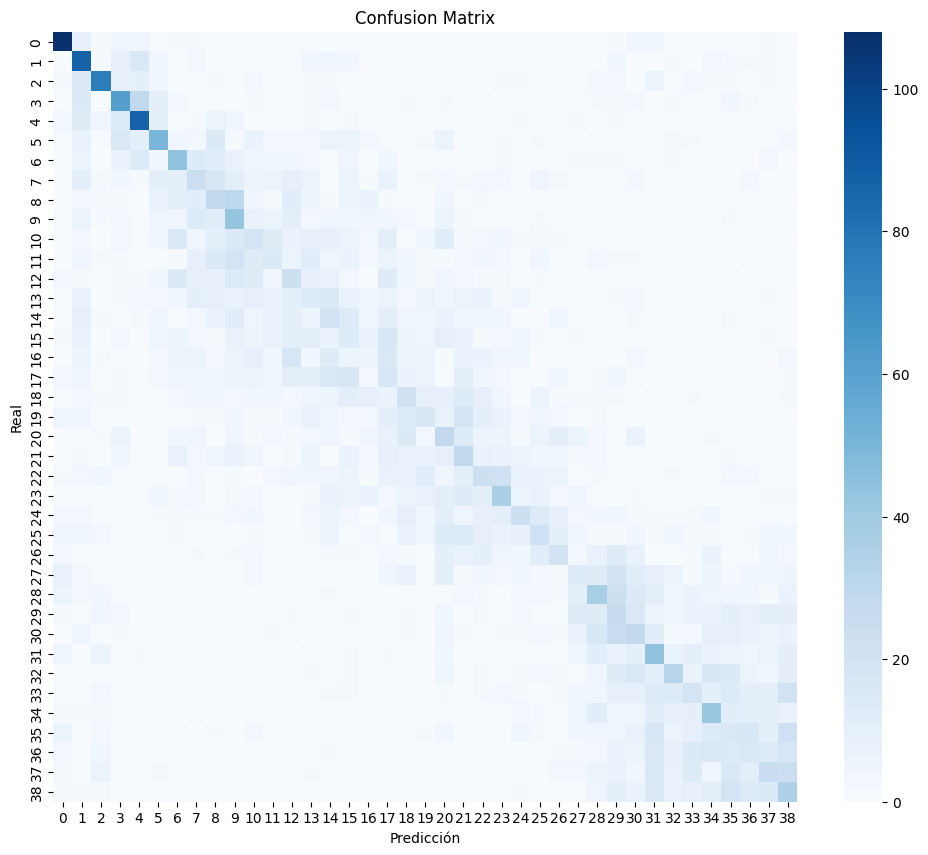

In [56]:
plt.figure(figsize=(12,10))

sns.heatmap(cm_df, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()


In [57]:
# Objetivo:
# Obtener las 30 palabras o n-gramas que el modelo considera más importantes
# para clasificar las décadas.

# obtener el pipeline entrenado
modelo = grid_mejor.best_estimator_

# obtener el vectorizador TF-IDF
vectorizador = modelo.named_steps["tfidf"]

# obtener nombres de features (palabras y ngramas)
feature_names = vectorizador.get_feature_names_out()

# obtener coeficientes del modelo
coef = modelo.named_steps["model"].coef_

# obtener top 30 features con mayor peso
top_features = np.argsort(coef[0])[-30:]

# imprimirlas
for i in top_features:
    print(feature_names[i])

cond
q
aragon
niet
luis
amad
calatrav
anterior
oe
duqu
manuscrit
orden
consej
tt
pleit
escritur
relacion
marques
francisc
extract
sobr
carl v
rey felip
carl
felip
caballer
juan
otorg
dij
cart


In [58]:
df_debug = pd.DataFrame({

    # texto original sin procesar
    "original": df.loc[X_test.index, "text"],

    # texto limpio + traducido
    "limpio": X_test,

    # clase real
    "real": y_test,

    # predicción del modelo
    "pred": y_pred

})

df_debug.head(10)


,original,limpio,real,pred
20364,\n‘rcargolabelaomcrcaduríaoil \nauíaen lacluda...,rcargolabelaomcrcaduríaoil auíaen lacludadef...,155,154
25605,\ne de Y 4 \n2... y \n; : \npa y \nLE ARA y) N...,e de y y pa y le ara y nn gua pe e...,177,160
27274,"Ptojófió del s, dineros fin jufticia.por ...",ptojófió del s dineros fin jufticia por fola ...,157,155
18623,"y , ? \nOA La > é ÓÚ có \no tp ; q E \nJ us ie...",y oa la é óú koko o tp q e jus ie a ferri doll...,165,160
33,'Donna tu li pigliarai la pedonna delta donna ...,mujer les tomaras el peon delta mujer con h ta...,156,156
10028,Y mil vezes nos hallamos \ndo los fueros traíp...,y mil vezes nos hallamos do los fueros traípaí...,155,160
19415,Otros están confitados en que con \ndar un sil...,otros están confitados en que con dar un silvi...,182,188
9247,En esos momentos los centro-americanos qu...,en esos momentos los centro americanos que veí...,188,183
3260,"Banliese,2 lo fpasio di tremiglia fuori d'una ...",banliese el pueblo de tremiglia en las afueras...,166,157
610,"Los Flamencos indufiriofos , de \nánimos candi...",los flamencos indufiriofos de ánimos candidq...,168,164


In [ ]:
X_test_clean = limpiar_texto(X_test.copy())
errores_mask = (y_pred != y_test)

df_errores = pd.DataFrame({

    "original": X_test[errores_mask],

    "limpio": X_test_clean[errores_mask],

    "real": y_test[errores_mask],

    "pred": y_pred[errores_mask]

})

df_errores["dist"] = abs(df_errores["real"] - df_errores["pred"])


pd.set_option("display.max_colwidth", 500)

df_errores.sort_values("dist", ascending=False).head(20)


,original,limpio,real,pred,dist
25467,"Lomas y Ca?ttoral, don Jerónimo de, autor entre otras obras poéticas \nde los Amores y muerte de Adonis.",lomas y ca ttoral don jerónimo de autor entre otras obras poéticas de los amores y muerte de adonis,188,150,38
27813,"\ngo, en nuestro tiempo se ha visto cómo micer Niccoló Vi- \ntelli? destruyó dos fortalezas en Cittá di Castello para con- \nservar aquel estado. Guido Ubaldo *%, duque de Urbino, de- \nmolió hasta los cimientos todas las fortalezas de aquel país \ncuando recuperó su dominio del que había sido expulsado \npor César Borja, porque juzgó que sin ellas le sería mucho \nmás difícil perder de nuevo su estado. Los Bentivoglio*!, \nde regreso a Bolonia, hicieron lo mismo. Por consiguiente, \nlas for...",go en nuestro tiempo se ha visto cómo micer niccoló vi telli destruyó dos fortalezas en cittá di castello para con servar aquel estado guido ubaldo duque de urbino de molió hasta los cimientos todas las fortalezas de aquel país cuando recuperó su dominio del que había sido expulsado por césar borja porque juzgó que sin ellas le sería mucho más difícil perder de nuevo su estado los bentivoglio de regreso a bolonia hicieron lo mismo por consiguiente las fortalezas son útiles o no según los ti...,151,188,37
26045,"Serrani, H. F. 1. 3. Epistole II ad O. Vanethi super Indicio Hiero- \nnimi Tiraboschide M. V. Martiale L. A. Séneca M. A. Lucano et \nAlis argent. Etatis Hispanis, Ferrarii 1776, in 8.*^",serrani h f l e epistole ii ad o vanethi super indicio hiero nimi tiraboschide m v martiale l a séneca m a lucano et alis argent etatis hispanis ferrarii l in,188,151,37
16648,"\ntro señor, firmada de su Real nonbre e refrendada por \nluanes de Saamano, su secretario, firmada de los seño¬ \nres del Consejo Real de Yndias e sellada con su sello \nReal pendiente, yncluso en madera, y escripta en per¬ \ngamino, en la qual está ynserto el aranzel que el Almi¬ \nrante de Castilla tiene por donde lleve los derechos al \ndicho oficio pertenecientes, para que se guarde e cunpla \nen -las partes de las Yndia...",tro señor firmada de su real nonbre e refrendada por luanes de saamano su secretario firmada de los seño res del consejo real de yndias e sellada con su sello real pendiente yncluso en madera y escripta en per gamino en la qual está ynserto el aranzel que el almi rante de castilla tiene por donde lleve los derechos al dicho oficio pertenecientes para que se guarde e cunpla en las partes de las yndias donde el dicho almirante don luis a de llevar derechos,187,150,37
23080,"Cuanto á lo que parece á v. md. que se debe escribir á Men- \ncía Alvarez, lo que por su carta me hace saber, apruebo, y si \nviniere á mi poder, venga abierta, porque sepa conformarme con \nvuestras palabras. Acerca de lo que en esta carta se escribe, \nharé relación adelante.",cuanto á lo que parece á v md que se debe escribir á men cía alvarez lo que por su carta me hace saber apruebo y si viniere á mi poder venga abierta porque sepa conformarme con vuestras palabras acerca de lo que en esta carta se escribe haré relación adelante,187,150,37
26252,Orden del marqués de Flores Dávila al contador Tomás de Gálvez para que diga las razones que ha \ntenido para no asistir a la distribución de granos de los almacenes reales.,orden del marqués de flores dávila al contador tomás de gálvez para que diga las razones que ha tenido para no asistir a la distribución de granos de los almacenes reales,150,187,37
11721,"Rubino, Beitrage zur Vorgescliichte Italiens. — Helwig B., Zur altitalischen kultur und íunsígeschíckte ; Leip- \n1878.",rubino beitrage zur vorgescliichte italiens helwig b zur altitalischen kultur und íunsígeschíckte leip l,188,151,37
16950,"Ahora, si consideráis de qué naturaleza era el gobierno \nde Darío*, lo encontraréis parecido al del Turco; por eso, \nAlejandro ya en el primer momento tuvo que atacar desde \ntodos los frentes y derrotarlo por completo; luego de la vic- \ntoria, muerto Darío, el estado quedó s

## Entrenar modelo Final

In [43]:
pipeline_final = best_model

NameError: name 'best_model' is not defined

In [ ]:
pipeline_final.fit(df["text"], df["decade"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function lim...001E1CC387380>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pa

In [ ]:
df_eval = pd.read_csv("./eval.csv")

print(df_eval.head())

pred = pipeline_final.predict(df_eval["text"])

   id  \
0   0   
1   1   
2   2   
3   3   
4   4   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  text  
0                                                                                                                                                                                                                                                                                                           P.  Si  en  efta  convocación  trato  folamente  de  comunicarles  los  artículos  arregla- \ndos, y firmados,  o de  proponerles , qué  pod

In [ ]:
submission = pd.DataFrame({

"id": df_eval["id"],

"answer": pred

})

submission.to_csv("./submission.csv", index=False)